# Bank Loan: OLS (Regression) + Classification (No Leakage)
End-to-end notebook with proper feature handling, model comparison, tuning, and evaluation.

## 1. Load Data

In [1]:
import pandas as pd

df = pd.read_csv("loan_processed_with_classification.csv")
df.rename(columns={df.columns[0]: "Index"}, inplace=True)
df.head()

,Index,log_rate,Interest_Rate,FICO_Range,Loan_Length,Amount_Funded_By_Investors,log_ar,Inquiries_in_the_Last_6_Months,Debt_To_Income_Ratio,Loan_Purpose_debt_consolidation,Loan_Purpose_major_purchase,Loan_Purpose_home_improvement,Home_Ownership_RENT,Home_Ownership_MORTGAGE,Loan_Purpose_car,Open_CREDIT_Lines,Revolving_CREDIT_Balance,Loan_Approved
0,0,2.186051,8.90,735.0,36.0,20000.0,9.903488,2.0,14.90,1,0,0,0,1,0,14.0,14272.0,1
1,1,2.494857,12.12,715.0,36.0,19200.0,9.862666,1.0,28.36,1,0,0,0,1,0,12.0,11140.0,0
2,2,3.090133,21.98,690.0,60.0,31000.0,10.419301,1.0,23.81,1,0,0,0,1,0,14.0,21977.0,0
3,3,2.301585,9.99,695.0,36.0,9975.0,9.210340,0.0,14.30,1,0,0,0,1,0,10.0,9346.0,0
4,4,2.460443,11.71,695.0,36.0,12000.0,9.392662,0.0,18.78,0,0,0,1,0,0,11.0,14469.0,0


## 2. Quick Checks

In [2]:
print(df.shape)
df.info()
df.describe().T

(2499, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Index                            2499 non-null   int64  
 1   log_rate                         2499 non-null   float64
 2   Interest_Rate                    2499 non-null   float64
 3   FICO_Range                       2499 non-null   float64
 4   Loan_Length                      2499 non-null   float64
 5   Amount_Funded_By_Investors       2499 non-null   float64
 6   log_ar                           2499 non-null   float64
 7   Inquiries_in_the_Last_6_Months   2499 non-null   float64
 8   Debt_To_Income_Ratio             2499 non-null   float64
 9   Loan_Purpose_debt_consolidation  2499 non-null   int64  
 10  Loan_Purpose_major_purchase      2499 non-null   int64  
 11  Loan_Purpose_home_improvement    2499 non-null   int64  
 12  Home_Owne

,count,mean,std,min,25%,50%,75%,max
Index,2499.0,1249.000000,721.543484,0.000000,624.500000,1249.000000,1873.500000,2498.000000
log_rate,2499.0,2.515406,0.338861,1.690096,2.318458,2.573375,2.760010,3.188829
Interest_Rate,2499.0,13.065734,4.173509,5.420000,10.160000,13.110000,15.800000,24.260000
FICO_Range,2499.0,705.655262,34.369002,640.000000,680.000000,700.000000,725.000000,792.500000
Loan_Length,2499.0,41.262905,9.932322,36.000000,36.000000,36.000000,36.000000,60.000000
Amount_Funded_By_Investors,2499.0,11921.492621,7520.627464,-0.010000,6000.000000,10000.000000,16000.000000,31000.000000
log_ar,2499.0,9.205676,0.706083,6.907755,8.699515,9.210340,9.740969,10.419301
Inquiries_in_the_Last_6_Months,2499.0,0.786114,0.905111,0.000000,0.000000,0.000000,1.000000,2.500000
Debt_To_Income_Ratio,2499.0,15.380420,7.505052,0.000000,9.750000,15.320000,20.675000,34.910000
Loan_Purpose_debt_consolidation,2499.0,0.522609,0.499589,0.000000,0.000000,1.000000,1.000000,1.000000


## 3. Define Targets and Remove Leakage Features
We REMOVE features used to create the target to avoid data leakage.

In [3]:
# Targets
y = df["Loan_Approved"]

# Remove leakage columns
X = df.drop(["Loan_Approved", "Interest_Rate", "log_rate"], axis=1)

X.head()

,Index,FICO_Range,Loan_Length,Amount_Funded_By_Investors,log_ar,Inquiries_in_the_Last_6_Months,Debt_To_Income_Ratio,Loan_Purpose_debt_consolidation,Loan_Purpose_major_purchase,Loan_Purpose_home_improvement,Home_Ownership_RENT,Home_Ownership_MORTGAGE,Loan_Purpose_car,Open_CREDIT_Lines,Revolving_CREDIT_Balance
0,0,735.0,36.0,20000.0,9.903488,2.0,14.90,1,0,0,0,1,0,14.0,14272.0
1,1,715.0,36.0,19200.0,9.862666,1.0,28.36,1,0,0,0,1,0,12.0,11140.0
2,2,690.0,60.0,31000.0,10.419301,1.0,23.81,1,0,0,0,1,0,14.0,21977.0
3,3,695.0,36.0,9975.0,9.210340,0.0,14.30,1,0,0,0,1,0,10.0,9346.0
4,4,695.0,36.0,12000.0,9.392662,0.0,18.78,0,0,0,1,0,0,11.0,14469.0


## 4. Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Model Training & Comparison

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    results[name] = acc

import pandas as pd
pd.DataFrame(list(results.items()), columns=["Model","Accuracy"]).sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.980
1,Decision Tree,0.970
0,Logistic Regression,0.892


## 7. Hyperparameter Tuning (Random Forest)

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


## 8. Final Model Evaluation

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.982

Confusion Matrix:
 [[348   5]
 [  4 143]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       353
           1       0.97      0.97      0.97       147

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



## 9. Feature Importance

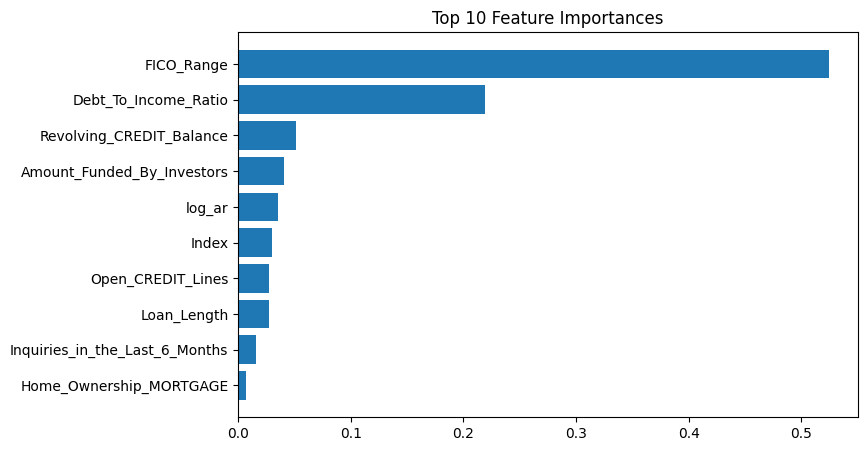

In [9]:
import numpy as np
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
# Map back to column names (X columns after drop)
feat_names = X.columns
idx = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(idx)), importances[idx])
plt.yticks(range(len(idx)), feat_names[idx])
plt.title("Top 10 Feature Importances")
plt.show()

## 10. Sample Prediction

In [10]:
sample = X_test[0].reshape(1, -1)
pred = best_model.predict(sample)[0]
print("Loan Approved" if pred == 1 else "Loan Rejected")

Loan Approved
